In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [5]:
T = 500  # timestep total
t = np.linspace(0, 4 * np.pi, T)
data = np.sin(t).astype(np.float32)  # shape: (T,)

# input: x[i] = sin(i), target: y[i] = sin(i+1)
seq_len = 20  # each sequence has 20 timesteps

X_list = []
Y_list = []

for i in range(T - seq_len - 1):
    X_list.append(data[i:i + seq_len])  # input: 20 timesteps
    Y_list.append(data[i + 1:i + seq_len + 1])  # 20 timesteps shifted by 1

X = torch.tensor(X_list).unsqueeze(-1)  # shape: (N, seq_len, 1)
Y = torch.tensor(Y_list).unsqueeze(-1)  # shape: (N, seq_len, 1)

# Train/test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

print(f"X_train shape: {X_train.shape}")  # (N_train, 20, 1)
print(f"Y_train shape: {Y_train.shape}")  # (N_train, 20, 1)

X_train shape: torch.Size([383, 20, 1])
Y_train shape: torch.Size([383, 20, 1])


In [6]:
class RNNScratch:
    def __init__(self, input_size, hidden_size, output_size):
        self.hidden_size = hidden_size  # fix 3: store for use in forward

        # weight: input -> hidden
        self.w_xh = torch.randn(input_size, hidden_size) * 0.1
        # weight: hidden -> hidden
        self.w_hh = torch.randn(hidden_size, hidden_size) * 0.1
        # bias hidden
        self.b_h = torch.zeros(hidden_size)
        # weight: hidden -> output
        self.w_hy = torch.randn(hidden_size, output_size) * 0.1
        # bias output
        self.b_y = torch.zeros(output_size)

        self.params = [self.w_xh, self.w_hh, self.b_h, self.w_hy, self.b_y]  # fix 1: include w_hh

        for p in self.params:
            p.requires_grad = True

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        batch_size, seq_len, _ = x.shape

        h = torch.zeros(batch_size, self.hidden_size)  # fix 3: use self.hidden_size

        outputs = []
        for t in range(seq_len):
            xt = x[:, t, :]  # fix 2: use loop variable t, not i
            h = torch.tanh(xt @ self.w_xh + h @ self.w_hh + self.b_h)

            y = h @ self.w_hy + self.b_y
            outputs.append(y.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)
        return outputs


In [9]:
input_size = 1
hidden_size = 32
output_size = 1
lr = 0.01
epochs = 100
batch_size = 64

model = RNNScratch(input_size, hidden_size, output_size)

for epoch in range(epochs):
    idx = torch.randperm(len(X_train))
    total_loss = 0.0
    n_batches = 0

    for start in range(0, len(X_train), batch_size):
        batch_idx = idx[start:start + batch_size]
        xb = X_train[batch_idx]  # (batch, seq_len, 1)
        yb = Y_train[batch_idx] # (batch, seq_len, 1)

        pred = model.forward(xb) # (batch, seq_len, 1)

        loss = ((pred - yb) ** 2).mean()

        loss.backward()

        with torch.no_grad():
            for p in model.params:
                p -= lr * p.grad
                p.grad.zero_()

        total_loss += loss.item()
        n_batches += 1

    if (epoch + 1) % 10 == 0:
        avg_loss = total_loss / n_batches
        print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.6f}")

Epoch  10 | Loss: 0.053812
Epoch  20 | Loss: 0.016094
Epoch  30 | Loss: 0.013213
Epoch  40 | Loss: 0.011144
Epoch  50 | Loss: 0.009573
Epoch  60 | Loss: 0.008337
Epoch  70 | Loss: 0.007341
Epoch  80 | Loss: 0.006528
Epoch  90 | Loss: 0.005846
Epoch 100 | Loss: 0.005274


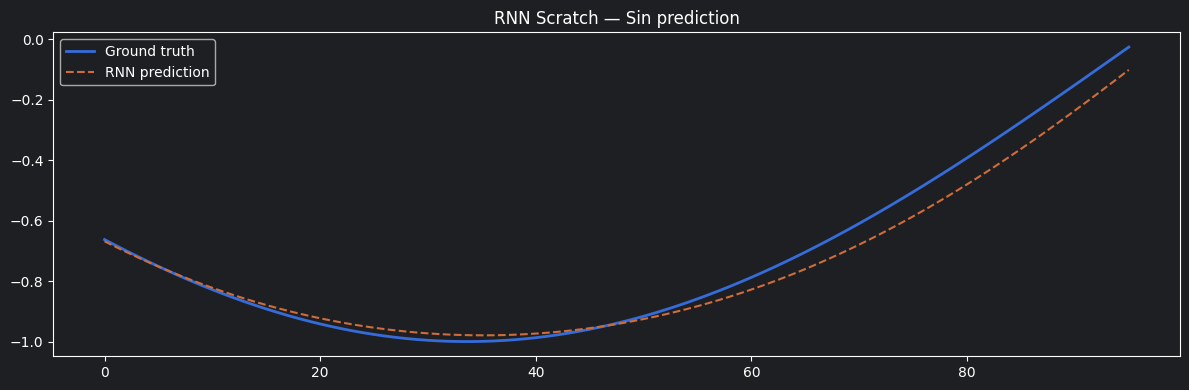

In [11]:
model_eval = model
with torch.no_grad():
    pred_test = model_eval.forward(X_test)  # (N_test, seq_len, 1)

# Lấy bước cuối của mỗi sequence để plot
true_vals = Y_test[:, -1, 0].numpy()
pred_vals = pred_test[:, -1, 0].numpy()

plt.figure(figsize=(12, 4))
plt.plot(true_vals[:100], label='Ground truth', linewidth=2)
plt.plot(pred_vals[:100], label='RNN prediction', linestyle='--')
plt.legend()
plt.title('RNN Scratch — Sin prediction')
plt.tight_layout()
plt.show()